# Customer Churn Prediction — Telco Dataset
**Project 4 of 10 — Data Analysis & ML Roadmap**

Predicting customer churn (binary classification) on the IBM/Kaggle Telco Customer Churn dataset. This notebook covers EDA, preprocessing, class imbalance handling, model comparison, and final model interpretation.

## 1. Setup & Load Data

In [3]:
# Core libraries for data handling and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the raw dataset
# NOTE: this notebook's kernel working directory is the project root
# (JupyterLab keeps the kernel cwd fixed to the server launch folder,
# not the notebook's own subfolder), so the path is relative to project root.
df = pd.read_csv('../data/data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Quick shape + dtype check
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data Cleaning

### 2.1 Fixing `TotalCharges`
`TotalCharges` loads as an `object` (text) column even though it looks numeric. Converting it reveals 11 rows that fail — every one of them has `tenure = 0`. These are brand-new customers who haven't completed a billing cycle yet, so the source system left the field blank instead of `0`. Since the correct value is logically known (0 months tenure -> $0 accumulated), we fill with 0 rather than drop these rows — dropping would discard 11 real customers over a data-entry quirk.

In [25]:
# How many rows fail numeric conversion?
pd.to_numeric(df['TotalCharges'], errors='coerce').isna().sum()

11

In [26]:
# Inspect the failing rows before fixing — confirm they're all tenure = 0
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()][
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [27]:
# Convert to numeric, then fill the logically-known blanks with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm the fix
print("Remaining NaNs:", df['TotalCharges'].isna().sum())
print("Dtype now:", df['TotalCharges'].dtype)

Remaining NaNs: 0
Dtype now: float64


### 2.2 Collapsing Redundant Categories

Seven columns (`MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) contain a third value like `"No phone service"` or `"No internet service"`. This is redundant — it's already captured by `PhoneService` / `InternetService` — so we collapse it into a plain `"No"`, turning these into clean binary columns without dropping any rows.

In [28]:
cols_to_fix = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:
    df[col] = df[col].replace({'No phone service': 'No',
                                'No internet service': 'No'})

# Confirm each column is now truly binary
for col in cols_to_fix:
    print(col, df[col].unique())

MultipleLines ['No' 'Yes']
OnlineSecurity ['No' 'Yes']
OnlineBackup ['Yes' 'No']
DeviceProtection ['No' 'Yes']
TechSupport ['No' 'Yes']
StreamingTV ['No' 'Yes']
StreamingMovies ['No' 'Yes']


## 3. Exploratory Data Analysis

### 3.1 Overall Churn Rate

This is the single most important number in the project — it establishes the class imbalance that shapes every modeling decision downstream.

In [29]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Finding:** ~73.5% of customers stayed, ~26.5% churned. A model that always predicts "no churn" would already score 73.5% accuracy — making plain accuracy a misleading metric on its own for this problem.

### 3.2 Tenure vs Churn

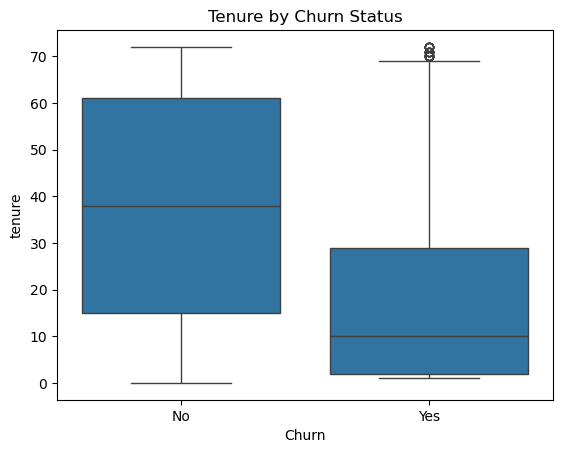

In [30]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure by Churn Status')
plt.show()

**Finding:** Customers who stayed have a median tenure of ~38 months; churned customers have a median of only ~10 months. The first several months of a customer relationship appear to be the highest-risk window for churn.

### 3.3 Contract Type vs Churn

In [31]:
# normalize='index' gives churn rate *within* each contract type —
# the right choice for comparing groups against each other
# (normalize=True would instead show each combo's share of the whole dataset)
print(pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


**Finding:** Month-to-month customers churn at 42.7%, vs 11.3% for one-year and just 2.8% for two-year contracts — roughly a 15x gap between the extremes. This is the single strongest churn signal found in EDA, likely because month-to-month contracts carry no penalty or switching cost for leaving at any time.

### 3.4 Internet Service Type vs Churn

In [32]:
print(pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


**Finding:** Fiber optic customers churn at 41.9%, vs 19.0% for DSL and 7.4% for customers with no internet service at all.

> **Domain insight (from prior telecom industry experience):** this likely reflects more than price sensitivity alone. Fiber installations are sometimes sold into areas where the underlying infrastructure can't fully support them, leading to a documented service-degradation case. Once flagged, customers rarely revert to DSL and most end up leaving instead of tolerating degraded service.

### 3.5 Payment Method vs Churn

In [33]:
print(pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


**Finding:** Electronic check has by far the highest churn rate (45.3%) of any payment method — nearly 3x every other method (15-19%).

> **Domain insight:** electronic check payments are more prone to silent failures (checks lost or dropped before reaching the company). Tracing a missing payment across both company and bank systems can take two or more weeks, during which service may be suspended. From the customer's perspective, they already paid — so the resulting confusion and frustration is often directed at the company rather than the actual point of failure, escalating into churn.

### 3.6 Monthly Charges vs Churn

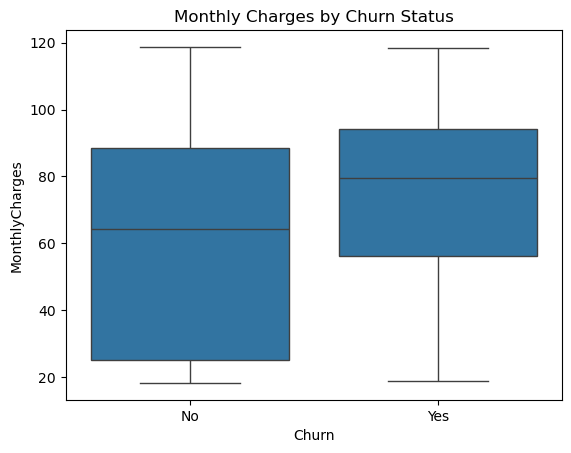

In [34]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')
plt.show()

**Finding:** Churned customers have a median monthly bill of ~$79 vs ~$64 for retained customers — confirming price sensitivity plays a real role alongside contract flexibility and service type.

## 4. Preprocessing

### 4.1 Drop Non-Predictive Columns

In [35]:
# customerID is a unique identifier with no predictive value — drop before modeling
df_model = df.drop(columns=['customerID'])
df_model.shape

(7043, 20)

### 4.2 Encode Binary Columns (Label Encoding)

For true Yes/No columns, we map explicitly (`No=0, Yes=1`) rather than relying on automatic encoders, so the mapping is unambiguous when interpreting coefficients later. `gender` has no natural order (Female/Male), so the mapping is arbitrary but must be documented: **Female=0, Male=1**.

In [36]:
df_model['gender'] = df_model['gender'].map({'Female': 0, 'Male': 1})

yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in yes_no_cols:
    df_model[col] = df_model[col].map({'No': 0, 'Yes': 1})

df_model[['gender'] + yes_no_cols].head()

,gender,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,0,1,0,0,0,0,1,0,0,0,0,1,0
1,1,0,0,1,0,1,0,1,0,0,0,0,0
2,1,0,0,1,0,1,1,0,0,0,0,1,1
3,1,0,0,0,0,1,0,1,1,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,1,1


### 4.3 Encode Multi-Category Columns (One-Hot Encoding)

`InternetService`, `Contract`, and `PaymentMethod` each have 3+ unordered categories — one-hot encoding avoids implying a false numeric order between them. `drop_first=True` drops one category per group to avoid redundant columns (the dropped category is implied when all remaining dummy columns are 0).

In [37]:
df_model = pd.get_dummies(
    df_model,
    columns=['InternetService', 'Contract', 'PaymentMethod'],
    drop_first=True
)
print(df_model.shape)
df_model.head()

(7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


### 4.4 Split Features and Target

In [38]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(X.shape, y.shape)

(7043, 23) (7043,)


### 4.5 Train/Test Split (Stratified)

`stratify=y` forces both the train and test sets to preserve the original 73.5% / 26.5% churn ratio. Without it, a random split could — purely by chance — leave the test set with a meaningfully different churn rate than what the model trained on, making evaluation misleading.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 23) (1409, 23)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## 5. Baseline Model — Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.801277501774308
[[925 110]
 [170 204]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



**Finding:** 80.1% accuracy sounds strong, but recall for churners is only 0.55 — the model misses nearly half of actual churners. This is the imbalance problem: accuracy alone hides poor performance on the minority (churn) class.

## 6. Handling Class Imbalance

### 6.1 `class_weight='balanced'` — Logistic Regression

Reweights the loss function so mistakes on the minority class (churners) count more heavily during training, forcing the model to pay attention to that class instead of leaning on easy majority-class wins.

In [41]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

[[748 287]
 [ 80 294]]
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



**Finding:** Recall for churners jumps from 0.55 -> 0.79, at the cost of precision (0.65 -> 0.51) and overall accuracy (80.1% -> 74.4%). This is the core imbalance tradeoff: catching more real churners means tolerating more false alarms.

### 6.2 Random Forest with `class_weight='balanced'`

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[933 102]
 [183 191]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



**Finding:** Random Forest's `class_weight='balanced'` behaves almost identically to the *plain, unweighted* Logistic Regression — it doesn't reproduce the recall jump seen above. Tree-based models apply class weighting per-tree/per-bootstrap-sample, which is a weaker lever than Logistic Regression's single global loss reweighting — the same parameter name doesn't guarantee the same strength of effect.

### 6.3 Hyperparameter Tuning with Bayesian Optimization

**What is Bayesian optimization?** Rather than blindly trying every combination (Grid Search) or random combinations (Random Search), Bayesian optimization builds a probabilistic model of how hyperparameters relate to performance based on trials already run, then uses that model to intelligently choose the next combination to try — balancing *exploitation* (nearby known-good regions) with *exploration* (unexplored regions that might hide something better). This typically reaches a strong result in far fewer trials than brute-force search.

We optimize directly for **recall**, since the business case (cheap retention offer vs. expensive customer loss) justifies prioritizing catching churners over avoiding false alarms.

In [43]:
from skopt import BayesSearchCV
from skopt.space import Integer

search_space = {
    'n_estimators': Integer(50, 300),
    'max_depth': Integer(3, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10)
}

bayes_search = BayesSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    search_space,
    n_iter=30,
    cv=5,                 # 5-fold cross-validation for a more reliable score per trial
    scoring='recall',      # optimize directly for the metric that matters for this business case
    random_state=42,
    n_jobs=-1
)

bayes_search.fit(X_train, y_train)
print(bayes_search.best_params_)

OrderedDict([('max_depth', 3), ('min_samples_leaf', 8), ('min_samples_split', 19), ('n_estimators', 280)])


In [44]:
best_rf = bayes_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))

[[736 299]
 [ 73 301]]
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



**Finding:** The tuned Random Forest reaches 0.80 recall — matching balanced Logistic Regression. Notably, the optimizer chose `max_depth=3`, the shallowest value allowed in the search range — a sign the model prefers simplicity, consistent with the churn signals being fairly strong and linearly separable.

### 6.4 SMOTE (Synthetic Minority Oversampling)

Unlike class weighting (which reweights existing rows), SMOTE generates new, synthetic churner examples by interpolating between real churners' nearest neighbors in feature space. **Applied to the training set only** — never the test set, which must stay untouched to represent real-world data honestly.

In [45]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


In [46]:
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

[[816 219]
 [126 248]]
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1035
           1       0.53      0.66      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.76      1409



**Finding:** SMOTE lands *between* the extremes (recall 0.66, precision 0.53) — it doesn't beat simple class weighting here. This makes sense: SMOTE tends to add the most value when the minority class has complex, non-linear patterns; our churn signals are comparatively strong and straightforward, so direct class weighting does the job just as well without the added complexity of synthetic data.

### 6.5 XGBoost (`scale_pos_weight`)

In [47]:
from xgboost import XGBClassifier

# scale_pos_weight mimics class_weight='balanced':
# ratio of majority-class count to minority-class count
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(scale_pos_weight=scale, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[829 206]
 [120 254]]
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1035
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



**Finding:** XGBoost also lands between the extremes (recall 0.68) and — importantly — its ROC-AUC (below) is slightly *lower* than both Logistic Regression and Random Forest, not higher. Model complexity alone does not improve the ceiling on this dataset.

## 7. ROC-AUC Comparison

ROC-AUC measures separation power across *all* thresholds, not just the default 0.5 cutoff used above — a fairer comparison of each model's underlying ability to rank churners as higher-risk than non-churners.

In [48]:
from sklearn.metrics import roc_auc_score

y_proba_lr = model_balanced.predict_proba(X_test)[:, 1]
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Balanced Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("Tuned Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

Balanced Logistic Regression ROC-AUC: 0.8385285075822161
Tuned Random Forest ROC-AUC: 0.8392957710093262
XGBoost ROC-AUC: 0.8210416182283189


### Full Model Comparison

| Model | Precision (Churn) | Recall (Churn) | F1 (Churn) | Accuracy | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression (plain) | 0.65 | 0.55 | 0.59 | 80.1% | — |
| Logistic Regression (balanced) | 0.51 | 0.79 | 0.62 | 74.4% | 0.839 |
| Random Forest (balanced, default) | 0.65 | 0.51 | 0.57 | 80.0% | — |
| Random Forest (balanced, Bayesian-tuned) | 0.50 | 0.80 | 0.62 | 74.0% | 0.839 |
| Logistic Regression + SMOTE | 0.53 | 0.66 | 0.59 | 76.4% | — |
| XGBoost (scale_pos_weight) | 0.55 | 0.68 | 0.61 | 77.0% | 0.821 |

**Conclusion:** all four modeling approaches converge to a near-identical ROC-AUC ceiling (~0.82–0.84). More complexity (Random Forest, XGBoost, SMOTE) does not meaningfully beat simple Logistic Regression here — the churn signal in this data is fairly linear.

**Final model: Logistic Regression (`class_weight='balanced'`)** — chosen over the marginally-tied tuned Random Forest because it achieves identical practical performance while being fully interpretable via its coefficients.

## 8. Final Model — Coefficient Interpretation

In [49]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_balanced.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
13,PaperlessBilling,0.504010
21,PaymentMethod_Electronic check,0.406909
16,InternetService_Fiber optic,0.356733
1,SeniorCitizen,0.293329
0,gender,0.174139
6,MultipleLines,0.119050
12,StreamingMovies,0.058374
2,Partner,0.050098
11,StreamingTV,0.047390
14,MonthlyCharges,0.016847


**Increases churn risk:**
- `PaperlessBilling` (+0.50)
- `PaymentMethod_Electronic check` (+0.41)
- `InternetService_Fiber optic` (+0.36)

**Decreases churn risk:**
- `Contract_Two year` (−0.68) — the single strongest effect in the model
- `TechSupport` (−0.58)
- `OnlineSecurity` (−0.57)

**A note on `tenure`:** despite a strong relationship with churn in EDA, its coefficient here is small (−0.05). This reflects **multicollinearity** with `Contract` type — long-tenure customers are disproportionately on 2-year contracts, so once Contract type is known, tenure has little *additional*, independent predictive power left to contribute. Contract type appears to be the more direct driver, with tenure partly acting as a proxy for the same underlying relationship — not evidence that tenure "doesn't matter."

## 9. Save Final Model for Deployment

In [50]:
import joblib

joblib.dump(model_balanced, 'model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']

A standalone Streamlit app (`app.py`) loads this saved model to provide an interactive churn risk predictor. Run locally with:

```bash
streamlit run app.py
```

In [51]:
X_train.dtypes.value_counts()
X_train.isna().sum().sum()

0

In [52]:
X_train['TotalCharges'].apply(lambda x: isinstance(x, str)).sum()

0